# 06 — Topic Review & Refinement

Now that NB 02 discovers topics data-driven (no predefined keywords), this notebook
helps you **review and iteratively improve** the topic model:

1. Inspect topic quality metrics (coherence, size distribution)
2. Find articles that are ambiguously assigned (multi-topic)
3. Check for any remaining 'noise' articles and characterise them
4. Optionally re-run NB 02 with adjusted hyperparameters

Input : `data/classified_articles.csv`, `data/topic_info.csv`  
No new output files — this is a diagnostic/review notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

df_all = pd.read_csv('data/classified_articles.csv', parse_dates=['date'])
topic_info = pd.read_csv('data/topic_info.csv')

print(f'Total rows (article × subtopic): {len(df_all):,}')
print(f'Unique articles   : {df_all["id"].nunique():,}')
print(f'Unique subtopics  : {df_all["subtopic"].nunique()}')
df_all['subtopic'].value_counts()

Total rows (article × subtopic): 12,447
Unique articles   : 4,490
Unique subtopics  : 12


subtopic
AI Safety               2029
OpenAI                  1597
Politics                1252
Social Media            1156
Legal                   1072
Stocks market           1069
Supply Chain            1058
Big Tech                 911
Flash news               899
Healthcare               545
Energy & Environment     476
Weather & Animal         383
Name: count, dtype: int64

## 1 — Topic Size Distribution

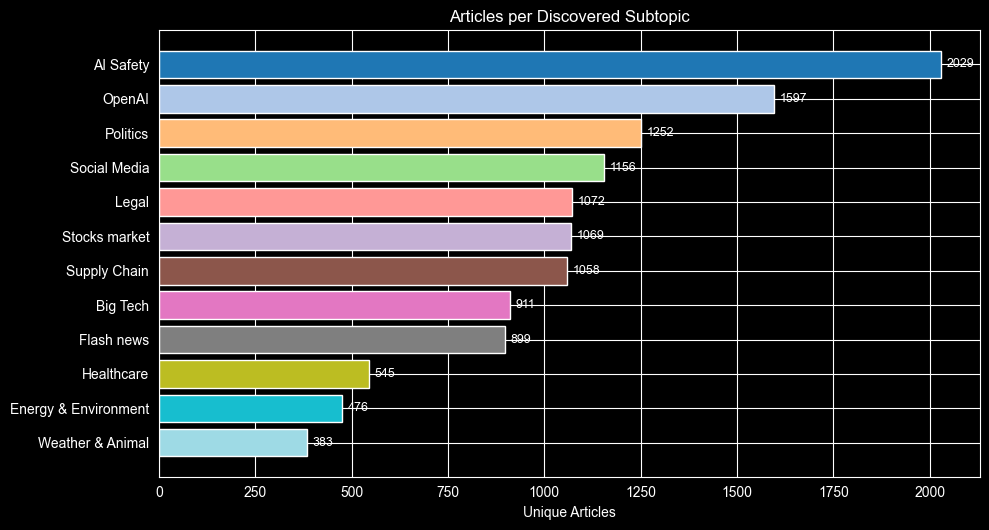


Topic keywords (from BERTopic):
  Social Media                    → ['tiktok', 'twitter', 'facebook', 'users', 'content', 'elon', 'children', 'musks', 'child', 'musk', 'ban', 'grok']
  AI Safety                       → ['summit', 'safety', 'ai safety', 'humanity', 'sunak', 'regulation', 'minister', 'rishi', 'bletchley', 'park', 'eu', 'bletchley park']
  OpenAI                          → ['openai', 'chatbot', 'altman', 'chatbots', 'sam', 'users', 'sam altman', 'apple', 'openais', 'microsoft', 'startup', 'mental']
  Politics                        → ['sunak', 'minister', 'war', 'labour', 'rishi', 'starmer', 'prime minister', 'rishi sunak', 'ukraine', 'election', 'trade', 'russia']
  Stocks market                   → ['nvidia', 'stock', 'shares', 'markets', 'wall', 'investors', 'wall street', 'chipmaker', 'index', 'inflation', 'bubble', 'crypto']
  Healthcare                      → ['cancer', 'nhs', 'patients', 'disease', 'doctors', 'brain', 'care', 'study', 'blood', 'medical', 'heart', 

In [2]:
# Unique articles per subtopic (deduplicated)
dist = (
    df_all.drop_duplicates(subset=['id', 'subtopic'])
    .groupby('subtopic')['id'].count()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, max(4, len(dist) * 0.45)))
colors = cm.tab20(np.linspace(0, 1, len(dist)))
bars = ax.barh(dist.index[::-1], dist.values[::-1], color=colors[::-1])
ax.bar_label(bars, fmt='%d', padding=4, fontsize=9)
ax.set_xlabel('Unique Articles')
ax.set_title('Articles per Discovered Subtopic')
plt.tight_layout()
plt.savefig('data/topic_size_distribution.png', dpi=150)
plt.show()

print('\nTopic keywords (from BERTopic):')
for _, row in topic_info.iterrows():
    print(f"  {row['subtopic_name']:30s}  → {row['Representation']}")

## 2 — Multi-Label Distribution
How many topics does each article get assigned to?

Labels per article:
subtopic
1     392
2     239
3    3859

Mean labels/article: 2.77


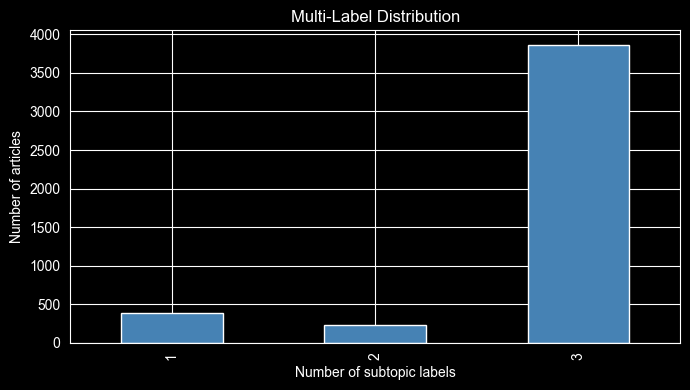

In [3]:
label_counts = df_all.groupby('id')['subtopic'].nunique()
print('Labels per article:')
print(label_counts.value_counts().sort_index().to_string())
print(f'\nMean labels/article: {label_counts.mean():.2f}')

fig, ax = plt.subplots(figsize=(7, 4))
label_counts.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of subtopic labels')
ax.set_ylabel('Number of articles')
ax.set_title('Multi-Label Distribution')
plt.tight_layout()
plt.show()

## 3 — Topic Overlap Heatmap
For multi-label articles, which topic pairs co-occur most often?

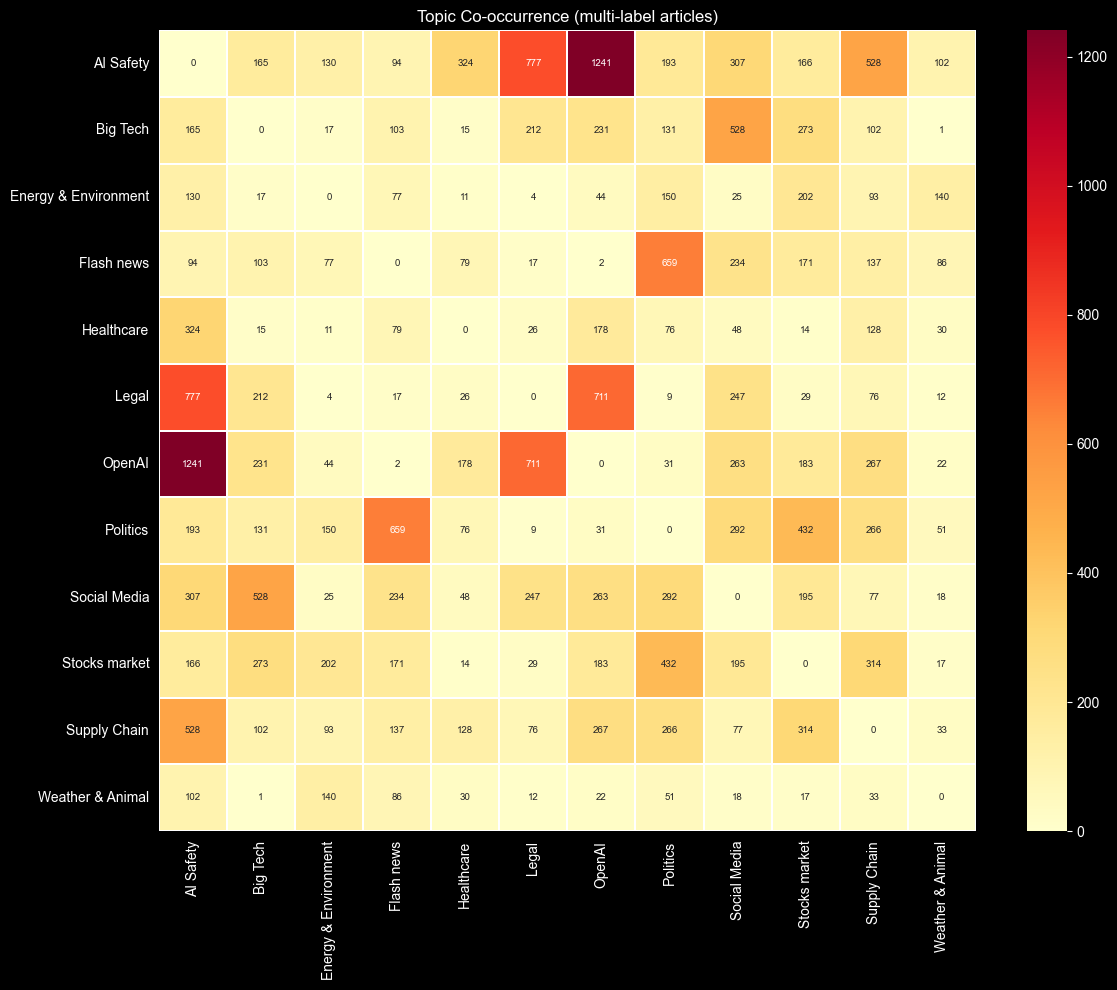

Saved: data/topic_cooccurrence.png


In [4]:
import seaborn as sns
from itertools import combinations

# Build co-occurrence matrix
multi = df_all.groupby('id')['subtopic'].apply(list)
topics_list = sorted(df_all['subtopic'].unique())
co = pd.DataFrame(0, index=topics_list, columns=topics_list)

for labels in multi:
    unique_labels = list(set(labels))
    for a, b in combinations(unique_labels, 2):
        co.loc[a, b] += 1
        co.loc[b, a] += 1

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    co, annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.3, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Topic Co-occurrence (multi-label articles)', fontsize=12)
plt.tight_layout()
plt.savefig('data/topic_cooccurrence.png', dpi=150)
plt.show()
print('Saved: data/topic_cooccurrence.png')

## 4 — Sample Headlines per Topic
Verify each topic makes sense by reading real headlines.

In [5]:
N_SAMPLE = 6  # headlines to show per topic

for topic_name, grp in df_all.groupby('subtopic'):
    unique_arts = grp.drop_duplicates('id')
    sample = unique_arts['headline'].sample(
        min(N_SAMPLE, len(unique_arts)), random_state=42
    )
    print(f'\n─── {topic_name} ({len(unique_arts):,} articles) ───')
    for h in sample:
        print(f'  • {h}')


─── AI Safety (2,029 articles) ───
  • AI bots could replace us, peer warns House of Lords during debate
  • Online manipulation expert Renée DiResta: ‘Conspiracy theories shape our politics in extremely mainstream ways’
  • UK ministers consider changing AI plans to protect creative industries
  • Facebook is ‘biased against facts’, says Nobel prize winner
  • EVs and datacentres driving new global ‘age of electricity’, says watchdog
  • Morning Mail: AI use by students grows, El Niño heatwaves warning, Nepal crash black boxes found

─── Big Tech (911 articles) ───
  • TikTok ‘acting too slow’ to tackle self-harm and eating disorder content
  • Mark Zuckerberg’s metaverse vision is over. Can Apple save it?
  • Google and Facebook urged by EU to label AI-generated content
  • Pixel 8 Pro: Google’s longer-lasting, AI-packed camera phone
  • Keir Starmer says media firms should have control of output used in AI
  • Was Darktrace’s surge a case of sentiment-driven investing on steroids?


## 5 — Tuning Guidance

If results aren't right, adjust these in NB 02 and re-run NB 02 → 03 → 04 → 05:

| Problem | Fix in NB 02 |
|---|---|
| Too few topics (< 10) | Lower `MIN_CLUSTER_SIZE` (e.g. `len(df) // 300`) |
| Too many topics (> 20) | Raise `MIN_CLUSTER_SIZE` or set `NR_TOPICS = 15` |
| Topics look too similar | Set `NR_TOPICS = 'auto'` or a lower integer to force merging |
| Too many articles get 2–3 labels | Raise `SIMILARITY_THRESHOLD` (e.g. 0.40) |
| Too many articles stuck at 1 label | Lower `SIMILARITY_THRESHOLD` (e.g. 0.22) |
| A topic is clearly noise | Map its `topic_id → None` in `TOPIC_NAME_MAP` |
| Two topics should merge | Give them the same name in `TOPIC_NAME_MAP` |

In [6]:
# Handy: show articles assigned to ONLY one topic that might be noise
# (high-confidence single assignment — inspect the bottom-ranked topics)
small_topics = dist[dist < 100].index.tolist()
if small_topics:
    print(f'Topics with < 100 articles (consider merging or discarding): {small_topics}')
    for t in small_topics:
        grp = df_all[df_all['subtopic'] == t].drop_duplicates('id')
        print(f'\n  [{t}]')
        for h in grp['headline'].head(5):
            print(f'    • {h}')
else:
    print('All topics have ≥ 100 articles. Distribution looks healthy.')

All topics have ≥ 100 articles. Distribution looks healthy.
